In [115]:
import numpy as np
import scipy as sp
from scipy.sparse.linalg import norm
import matplotlib.pyplot as plt
import openfermion as of
from openfermionpyscf import run_pyscf
import qiskit
from qiskit.qasm2 import dumps
import quimb.tensor as qtn
from quimb.tensor.tensor_1d import MatrixProductState
from quimb_tebd import (
    pauli_sum_to_mpo, get_drmg_ground_state, trotter_circuit_from_psum,
    energy_vs_d, get_evolved_states, fill_subspace_matrices_mps,
    exact_evolved_states, mps_to_vector, fill_subspace_matrices_vectors
)

In [116]:
molec = "hydrogen"
basis = "sto-3g"
n_elec = 2
geometry = of.chem.geometry_from_pubchem(molec)
multiplicity = 1
dmrg_max_bond = 1
tebd_max_bond = 500
tau = 0.1
steps = 10

In [117]:
# Get the Hamiltonian.
molecule = of.chem.MolecularData(
    geometry, basis, multiplicity
)
molecule = run_pyscf(molecule, run_scf=1, run_fci=1)
print(f"HF energy:", molecule.hf_energy)
print(f"FCI energy:", molecule.fci_energy)
hamiltonian = molecule.get_molecular_hamiltonian()
hamiltonian_qubop = of.transforms.jordan_wigner(hamiltonian)
hamiltonian_psum = of.transforms.qubit_operator_to_pauli_sum(hamiltonian_qubop)
qs = hamiltonian_psum.qubits
hamiltonian_mpo = pauli_sum_to_mpo(hamiltonian_psum, qs, dmrg_max_bond)
nq = len(hamiltonian_mpo.tensors)
print(f"Hamiltonian has {nq} sites")

HF energy: -1.0661086493179366
FCI energy: -1.1011503302326182
Hamiltonian has 4 sites


In [118]:
# Run DMRG
ground_state, energy, number = get_drmg_ground_state(hamiltonian_mpo, n_elec, dmrg_max_bond)
print(f"DMRG ground state has energy {energy} and occupation {number}.")
ground_max_bond = np.max(ground_state.bond_sizes())
print(f"Ground state has maximum bond dim {ground_max_bond}.")

DMRG ground state has energy -0.25788407735247726 and occupation 1.9999999999999998.
Ground state has maximum bond dim 1.


In [119]:
evolution_circuit = trotter_circuit_from_psum(hamiltonian_psum, tau, steps)
ev_circuit_transpiled = qiskit.transpile(evolution_circuit)
qasm_str = dumps(evolution_circuit)

## Evolve the DMRG ground state.

In [120]:
bond_sizes = []
evolved_mps = ground_state.copy()
for i in range(steps):
    print(f"On step {i}/{steps}")
    bond_sizes.append(evolved_mps.bond_sizes())
    circuit_mps = qtn.circuit.CircuitMPS.from_openqasm2_str(
        qasm_str, psi0=evolved_mps, max_bond=tebd_max_bond, progbar=False
    )
    evolved_mps = circuit_mps.psi
bond_sizes = np.array(bond_sizes)

On step 0/10
On step 1/10
On step 2/10
On step 3/10
On step 4/10
On step 5/10
On step 6/10
On step 7/10
On step 8/10
On step 9/10


In [121]:
bond_dim_avg = np.average(bond_sizes, axis=1)
bond_dim_max = np.max(bond_sizes, axis=1)
bond_dim_min = np.min(bond_sizes, axis=1)

## Repeat with a random state.

In [122]:
psi = np.random.rand(2 ** nq)
psi_mps = MatrixProductState.from_dense(psi)
psi_mps.compress(max_bond=1)

In [123]:
random_bond_sizes = []
evolved_mps = psi_mps.copy()
for i in range(steps):
    print(f"On step {i}/{steps}")
    random_bond_sizes.append(evolved_mps.bond_sizes())
    circuit_mps = qtn.circuit.CircuitMPS.from_openqasm2_str(
        qasm_str, psi0=evolved_mps, max_bond=tebd_max_bond, progbar=False
    )
    evolved_mps = circuit_mps.psi
random_bond_sizes = np.array(random_bond_sizes)

On step 0/10
On step 1/10
On step 2/10
On step 3/10
On step 4/10
On step 5/10
On step 6/10
On step 7/10
On step 8/10
On step 9/10


In [124]:
random_bond_dim_avg = np.average(random_bond_sizes, axis=1)
random_bond_dim_max = np.max(random_bond_sizes, axis=1)
random_bond_dim_min = np.min(random_bond_sizes, axis=1)

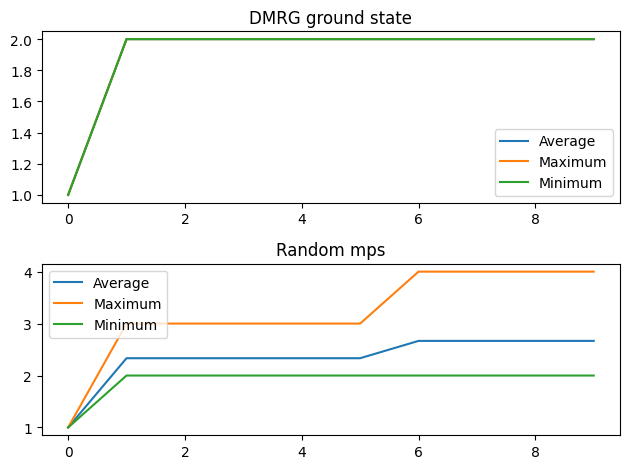

In [125]:
fig, ax = plt.subplots(2)
ax[0].plot(bond_dim_avg, label="Average")
ax[0].plot(bond_dim_max, label="Maximum")
ax[0].plot(bond_dim_min, label="Minimum")
ax[0].legend()
ax[0].set_title("DMRG ground state")
ax[1].plot(random_bond_dim_avg, label="Average")
ax[1].plot(random_bond_dim_max, label="Maximum")
ax[1].plot(random_bond_dim_min, label="Minimum")
ax[1].legend()
ax[1].set_title("Random mps")
fig.tight_layout()